In [1]:
!pip install pyspark findspark -q

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EuropeanLuxuryRealEstateOLAP") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("SparkSession creada correctamente")

SparkSession creada correctamente


In [5]:
import pandas as pd

BASE = "https://raw.githubusercontent.com/joterojordanufv/TrabajoFinalBigData/main/data/final/"

fact_pd = pd.read_csv(BASE + "fact_properties.csv")
dim_city_pd = pd.read_csv(BASE + "dim_city.csv")
dim_neighborhood_pd = pd.read_csv(BASE + "dim_neighborhood.csv")
dim_property_type_pd = pd.read_csv(BASE + "dim_property_type.csv")
dim_source_pd = pd.read_csv(BASE + "dim_source.csv")
dim_time_pd = pd.read_csv(BASE + "dim_time.csv")
dim_luxury_segment_pd = pd.read_csv(BASE + "dim_luxury_segment.csv")

fact_properties = spark.createDataFrame(fact_pd)
dim_city = spark.createDataFrame(dim_city_pd)
dim_neighborhood = spark.createDataFrame(dim_neighborhood_pd)
dim_property_type = spark.createDataFrame(dim_property_type_pd)
dim_source = spark.createDataFrame(dim_source_pd)
dim_time = spark.createDataFrame(dim_time_pd)
dim_luxury_segment = spark.createDataFrame(dim_luxury_segment_pd)

print("Tablas cargadas correctamente")
print(f"Fact rows: {fact_properties.count()}")

Tablas cargadas correctamente
Fact rows: 150078


In [6]:
real_estate_df = (
    fact_properties
    .join(dim_city, "city_id", "left")
    .join(dim_neighborhood, "neighborhood_id", "left")
    .join(dim_property_type, "property_type_id", "left")
    .join(dim_source, "source_id", "left")
    .join(dim_time, "time_id", "left")
    .join(dim_luxury_segment, "luxury_segment_id", "left")
)

real_estate_df.printSchema()
real_estate_df.show(5)

root
 |-- luxury_segment_id: long (nullable = true)
 |-- time_id: long (nullable = true)
 |-- source_id: long (nullable = true)
 |-- property_type_id: long (nullable = true)
 |-- neighborhood_id: long (nullable = true)
 |-- city_id: long (nullable = true)
 |-- fact_id: long (nullable = true)
 |-- source_record_id: string (nullable = true)
 |-- load_timestamp: string (nullable = true)
 |-- price_eur: double (nullable = true)
 |-- area_m2: double (nullable = true)
 |-- bedrooms: double (nullable = true)
 |-- bathrooms: double (nullable = true)
 |-- price_per_m2: double (nullable = true)
 |-- luxury_threshold_country: double (nullable = true)
 |-- city: string (nullable = true)
 |-- country: string (nullable = true)
 |-- neighborhood: string (nullable = true)
 |-- city_id: long (nullable = true)
 |-- property_type: string (nullable = true)
 |-- source: string (nullable = true)
 |-- scraping_date: string (nullable = true)
 |-- year: long (nullable = true)
 |-- quarter: long (nullable = tru

In [7]:
real_estate_df.createOrReplaceTempView("real_estate")
fact_properties.createOrReplaceTempView("fact_properties")
dim_city.createOrReplaceTempView("dim_city")
dim_luxury_segment.createOrReplaceTempView("dim_luxury_segment")

print("Vistas temporales creadas")

Vistas temporales creadas


In [8]:
q1 = spark.sql("""
SELECT
    country,
    luxury_label,
    ROUND(AVG(price_eur), 2) AS avg_price,
    ROUND(AVG(price_per_m2), 2) AS avg_price_m2,
    COUNT(*) AS total_properties
FROM real_estate
WHERE luxury_label = 'Luxury'
GROUP BY country, luxury_label
ORDER BY avg_price DESC
""")

q1.show()

+--------------+------------+----------+------------+----------------+
|       country|luxury_label| avg_price|avg_price_m2|total_properties|
+--------------+------------+----------+------------+----------------+
|         Spain|      Luxury|1697807.38|    20274.86|            9506|
|   Netherlands|      Luxury|1334778.14|      1435.9|             563|
|United Kingdom|      Luxury| 718340.67|     5829.15|            5001|
+--------------+------------+----------+------------+----------------+



In [9]:
q2 = spark.sql("""
SELECT
    country,
    city,
    ROUND(AVG(price_eur), 2) AS avg_price,
    ROUND(AVG(price_per_m2), 2) AS avg_price_m2,
    COUNT(*) AS total_properties
FROM real_estate
GROUP BY country, city
HAVING COUNT(*) >= 30
ORDER BY avg_price DESC
LIMIT 15
""")

q2.show()

+-----------+--------------------+----------+------------+----------------+
|    country|                city| avg_price|avg_price_m2|total_properties|
+-----------+--------------------+----------+------------+----------------+
|      Spain|Sant Joan De Labr...|2088108.08|     1243.64|              73|
|      Spain|Sant Josep De Sa ...|1506392.79|     2743.63|             946|
|      Spain|                Deya|1479739.66|     3974.88|              58|
|      Spain|          Formentera| 1437300.0|     2721.08|             100|
|      Spain|Santa Eulalia Del...|1382793.64|      3020.4|             987|
|      Spain|            Esporles|1334118.31|     2792.24|             211|
|      Spain|         Valldemossa| 1231725.8|    60503.41|             131|
|      Spain|              Calvià|1150767.09|     5154.53|            2297|
|      Spain|Santa Maria Del Cami|1129051.02|      1284.7|             166|
|      Spain|Sant Llorenç Des ...|1056560.88|     2585.36|              76|
|      Spain

In [10]:
q3 = spark.sql("""
SELECT
    property_type,
    luxury_label,
    COUNT(*) AS total_properties,
    ROUND(AVG(price_eur), 2) AS avg_price
FROM real_estate
WHERE luxury_label = 'Luxury'
GROUP BY property_type, luxury_label
ORDER BY total_properties DESC
""")

q3.show()

+-------------------+------------+----------------+----------+
|      property_type|luxury_label|total_properties| avg_price|
+-------------------+------------+----------------+----------+
|              Villa|      Luxury|            5796|1802125.13|
|          Apartment|      Luxury|            3026|1175927.11|
|     Detached House|      Luxury|            2449| 646607.47|
|              Other|      Luxury|            1126|2020602.83|
|Semi-Detached House|      Luxury|             814|  604875.1|
|     Terraced House|      Luxury|             795| 731410.86|
|              House|      Luxury|             672|1463931.19|
|          Penthouse|      Luxury|             392| 1437356.7|
+-------------------+------------+----------------+----------+



In [11]:
q4 = spark.sql("""
SELECT
    year,
    country,
    ROUND(AVG(price_eur), 2) AS avg_price,
    COUNT(*) AS total_properties
FROM real_estate
GROUP BY year, country
ORDER BY year, country
""")

q4.show()

+----+--------------+---------+----------------+
|year|       country|avg_price|total_properties|
+----+--------------+---------+----------------+
|1995|United Kingdom| 78315.95|            1782|
|1996|United Kingdom| 84989.34|            2182|
|1997|United Kingdom| 93999.13|            2466|
|1998|United Kingdom|100738.18|            2288|
|1999|United Kingdom|113456.43|            2624|
|2000|United Kingdom|127177.74|            2473|
|2001|United Kingdom|139152.67|            2727|
|2002|United Kingdom| 163347.4|            3063|
|2003|United Kingdom|184854.93|            2762|
|2004|United Kingdom|212714.53|            2801|
|2005|United Kingdom|219621.72|            2355|
|2006|United Kingdom|239347.61|            2990|
|2007|United Kingdom|262597.61|            2828|
|2008|United Kingdom|258330.57|            1431|
|2009|United Kingdom|244333.78|            1362|
|2010|United Kingdom|275492.51|            1448|
|2011|United Kingdom|277067.65|            1530|
|2012|United Kingdom

In [12]:
q5 = spark.sql("""
SELECT
    country,
    luxury_label,
    ROUND(AVG(price_eur), 2) AS avg_price,
    ROUND(AVG(price_per_m2), 2) AS avg_price_m2,
    ROUND(AVG(area_m2), 2) AS avg_area,
    COUNT(*) AS total_properties
FROM real_estate
GROUP BY country, luxury_label
ORDER BY country, luxury_label
""")

q5.show()

+--------------+------------+----------+------------+--------+----------------+
|       country|luxury_label| avg_price|avg_price_m2|avg_area|total_properties|
+--------------+------------+----------+------------+--------+----------------+
|   Netherlands|      Luxury|1334778.14|      1435.9|   113.0|             563|
|   Netherlands|    Standard| 470447.18|      1435.9|   113.0|            4992|
|         Spain|      Luxury|1697807.38|    20274.86|10223.21|            9506|
|         Spain|    Standard|  232003.9|     1868.07|  813.19|           85017|
|United Kingdom|      Luxury| 718340.67|     5829.15|  141.37|            5001|
|United Kingdom|    Standard| 154257.63|     1315.49|  123.68|           44999|
+--------------+------------+----------+------------+--------+----------------+



In [13]:
from pyspark.sql.functions import avg, count

rollup_result = (
    real_estate_df
    .rollup("country", "luxury_label")
    .agg(
        avg("price_eur").alias("avg_price"),
        avg("price_per_m2").alias("avg_price_m2"),
        count("*").alias("total_properties")
    )
    .orderBy("country", "luxury_label")
)

rollup_result.show()

+--------------+------------+------------------+------------------+----------------+
|       country|luxury_label|         avg_price|      avg_price_m2|total_properties|
+--------------+------------+------------------+------------------+----------------+
|          NULL|        NULL| 329811.4679242771|2984.2772501633603|          150078|
|   Netherlands|        NULL| 558047.2392439244| 1435.900000000142|            5555|
|   Netherlands|      Luxury| 1334778.136767318|1435.9000000000144|             563|
|   Netherlands|    Standard|  470447.180088141| 1435.900000000116|            4992|
|         Spain|        NULL| 379416.9923828063| 3719.206039059299|           94523|
|         Spain|      Luxury|1697807.3790237745|20274.861738901847|            9506|
|         Spain|    Standard|232003.89834974182|1868.0696418363334|           85017|
|United Kingdom|        NULL| 210677.2139627943| 1766.948484399981|           50000|
|United Kingdom|      Luxury| 718340.6654469117| 5829.14825034992

In [14]:
cube_result = (
    real_estate_df
    .cube("country", "property_type", "luxury_label")
    .agg(
        avg("price_eur").alias("avg_price"),
        count("*").alias("total_properties")
    )
    .orderBy("country", "property_type", "luxury_label")
)

cube_result.show(30)

+-----------+-------------------+------------+------------------+----------------+
|    country|      property_type|luxury_label|         avg_price|total_properties|
+-----------+-------------------+------------+------------------+----------------+
|       NULL|               NULL|        NULL| 329811.4679242771|          150078|
|       NULL|               NULL|      Luxury|1359207.6114067684|           15070|
|       NULL|               NULL|    Standard|214907.16682892575|          135008|
|       NULL|          Apartment|        NULL|244097.98738104134|           61765|
|       NULL|          Apartment|      Luxury| 1175927.109289491|            3026|
|       NULL|          Apartment|    Standard|196093.85174892348|           58739|
|       NULL|     Detached House|        NULL| 294187.0549475248|           11624|
|       NULL|     Detached House|      Luxury| 646607.4679256843|            2449|
|       NULL|     Detached House|    Standard| 200118.6526168952|            9175|
|   

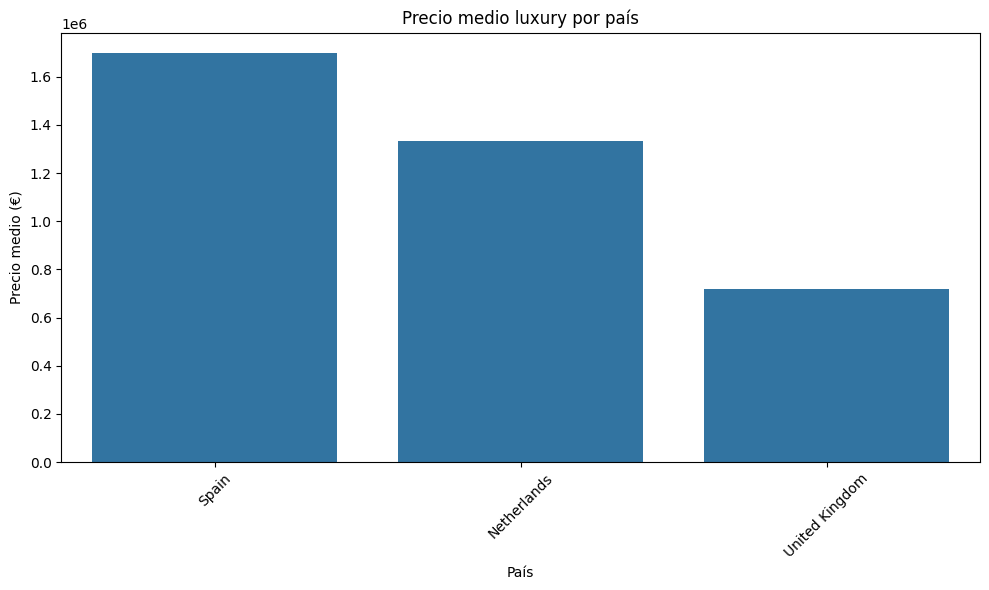

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

q1_pd = q1.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=q1_pd, x="country", y="avg_price")
plt.title("Precio medio luxury por país")
plt.xlabel("País")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

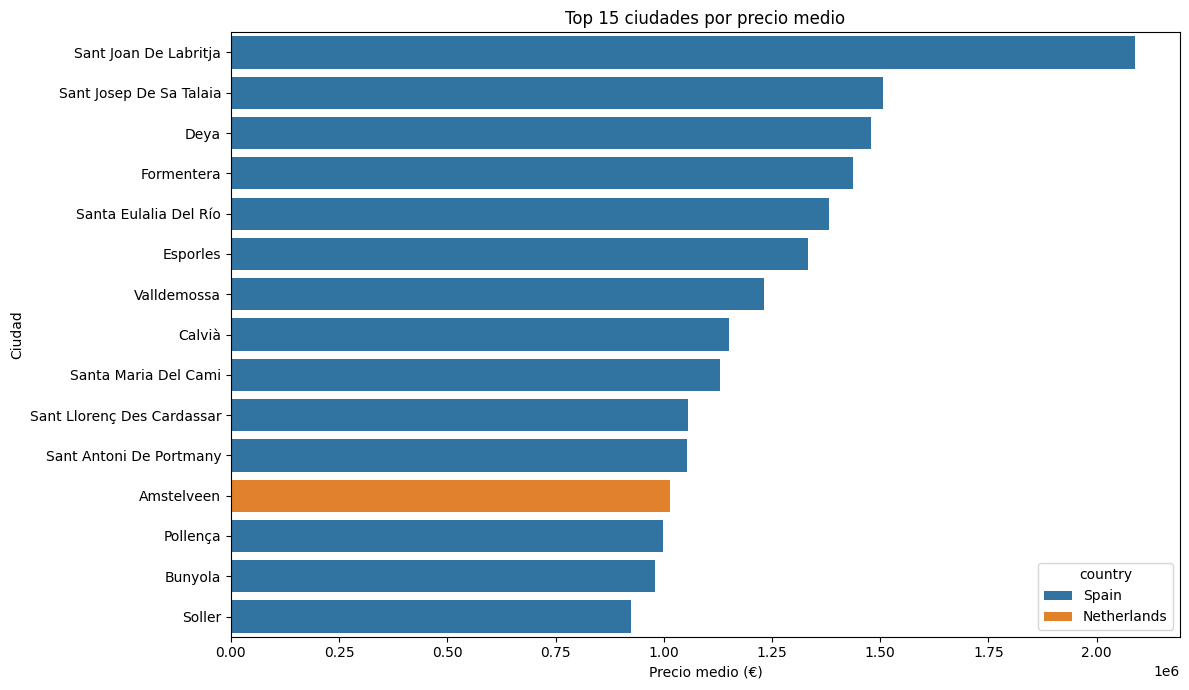

In [16]:
q2_pd = q2.toPandas()

plt.figure(figsize=(12,7))
sns.barplot(data=q2_pd, x="avg_price", y="city", hue="country")
plt.title("Top 15 ciudades por precio medio")
plt.xlabel("Precio medio (€)")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

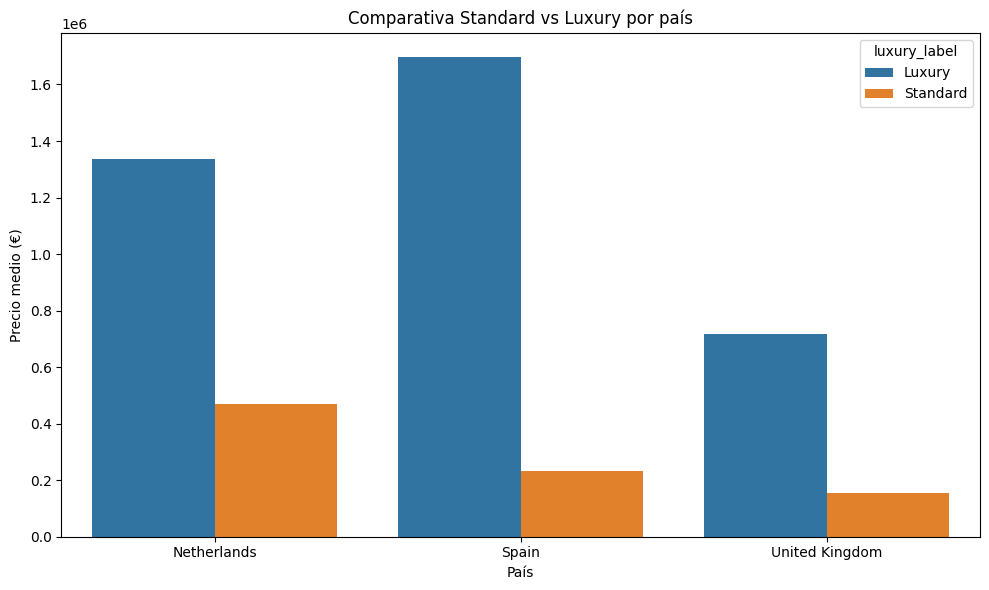

In [17]:
q5_pd = q5.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=q5_pd, x="country", y="avg_price", hue="luxury_label")
plt.title("Comparativa Standard vs Luxury por país")
plt.xlabel("País")
plt.ylabel("Precio medio (€)")
plt.tight_layout()
plt.show()